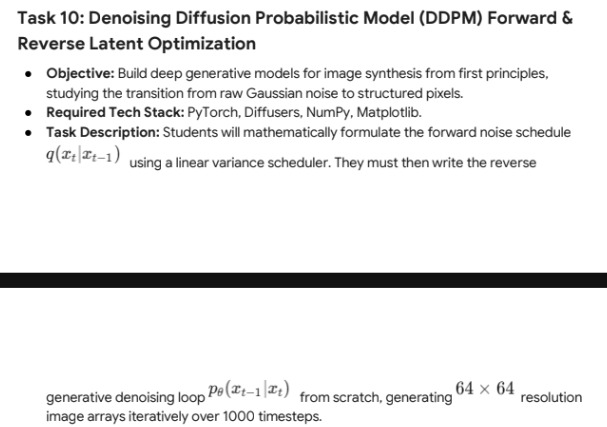

In [ ]:
!pip install torch torchvision matplotlib pillow

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Dataset size:", len(dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 148MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 51.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 70.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.99MB/s]


Dataset size: 60000


In [ ]:
T = 1000

beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(
    beta_start,
    beta_end,
    T
).to(device)

alphas = 1.0 - betas

alpha_bar = torch.cumprod(
    alphas,
    dim=0
)

print("Number of diffusion steps:", T)

Number of diffusion steps: 1000


In [ ]:
def forward_diffusion(
    x0,
    timestep
):

    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(
        alpha_bar[timestep]
    ).view(-1, 1, 1, 1)

    sqrt_one_minus_alpha_bar = torch.sqrt(
        1 - alpha_bar[timestep]
    ).view(-1, 1, 1, 1)

    xt = (
        sqrt_alpha_bar * x0
        +
        sqrt_one_minus_alpha_bar * noise
    )

    return xt, noise

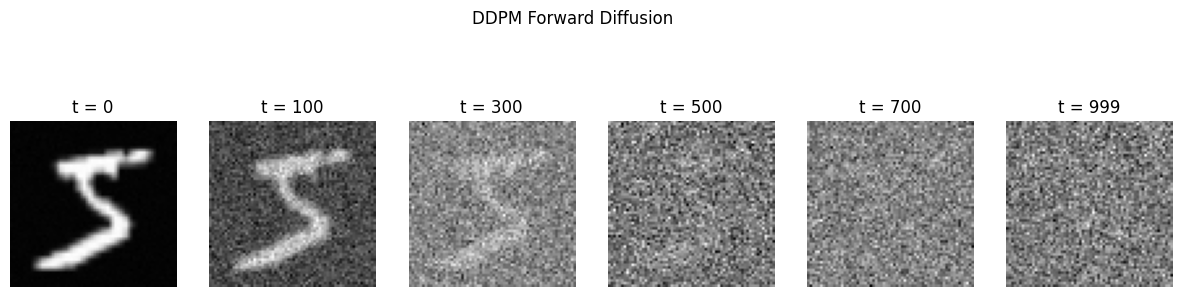

In [ ]:
image, _ = dataset[0]

image = image.unsqueeze(0).to(device)

timesteps = [
    0,
    100,
    300,
    500,
    700,
    999
]

plt.figure(figsize=(15, 4))

for i, t in enumerate(timesteps):

    t_tensor = torch.tensor(
        [t],
        device=device
    )

    noisy_image, _ = forward_diffusion(
        image,
        t_tensor
    )

    plt.subplot(
        1,
        len(timesteps),
        i + 1
    )

    plt.imshow(
        noisy_image[0, 0]
        .detach()
        .cpu()
        .numpy(),
        cmap="gray"
    )

    plt.title(
        f"t = {t}"
    )

    plt.axis("off")

plt.suptitle(
    "DDPM Forward Diffusion"
)

plt.show()

In [ ]:
class SimpleDenoiser(nn.Module):

    def __init__(self):

        super().__init__()

        self.time_embedding = nn.Embedding(
            1000,
            64
        )

        self.conv1 = nn.Conv2d(
            1,
            32,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            32,
            64,
            3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            64,
            32,
            3,
            padding=1
        )

        self.conv4 = nn.Conv2d(
            32,
            1,
            3,
            padding=1
        )

        self.time_layer = nn.Linear(
            64,
            64
        )

    def forward(
        self,
        x,
        t
    ):

        time_emb = self.time_embedding(t)

        time_emb = self.time_layer(
            time_emb
        )

        time_emb = time_emb[:, :, None, None]

        h = F.relu(
            self.conv1(x)
        )

        h = F.relu(
            self.conv2(h)
            +
            time_emb
        )

        h = F.relu(
            self.conv3(h)
        )

        output = self.conv4(h)

        return output

In [ ]:
model = SimpleDenoiser().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)

SimpleDenoiser(
  (time_embedding): Embedding(1000, 64)
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_layer): Linear(in_features=64, out_features=64, bias=True)
)


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

loss_history = []

epochs = 2

for epoch in range(epochs):

    total_loss = 0

    for batch_idx, (images, _) in enumerate(loader):

        images = images.to(device)

        batch_size = images.shape[0]

        t = torch.randint(
            0,
            T,
            (batch_size,),
            device=device
        )

        noisy_images, noise = forward_diffusion(
            images,
            t
        )

        predicted_noise = model(
            noisy_images,
            t
        )

        loss = F.mse_loss(
            predicted_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        if batch_idx >= 100:
            break

    average_loss = (
        total_loss /
        (batch_idx + 1)
    )

    loss_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/2 Loss: 0.2255
Epoch 2/2 Loss: 0.1035


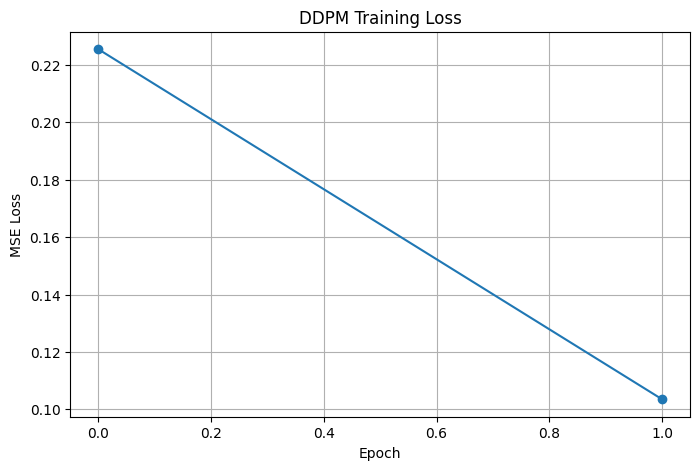

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "DDPM Training Loss"
)

plt.grid()

plt.show()

In [ ]:
@torch.no_grad()
def reverse_diffusion():

    x = torch.randn(
        1,
        1,
        64,
        64,
        device=device
    )

    for t in reversed(range(T)):

        t_tensor = torch.tensor(
            [t],
            device=device
        )

        predicted_noise = model(
            x,
            t_tensor
        )

        alpha_t = alphas[t]

        alpha_bar_t = alpha_bar[t]

        beta_t = betas[t]

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                beta_t /
                torch.sqrt(
                    1 - alpha_bar_t
                )
            )
            * predicted_noise
        )

        if t > 0:

            noise = torch.randn_like(x)

            x += torch.sqrt(
                beta_t
            ) * noise

    return x

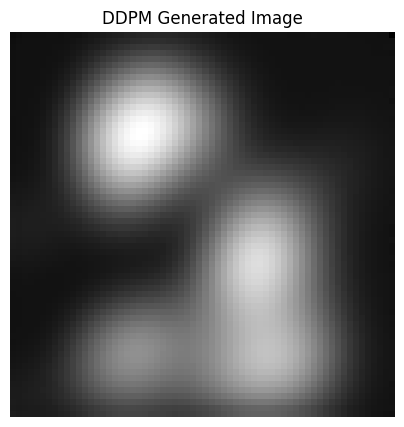

In [ ]:
generated_image = reverse_diffusion()

generated_image = (
    generated_image[0, 0]
    .cpu()
    .numpy()
)

plt.figure(figsize=(5, 5))

plt.imshow(
    generated_image,
    cmap="gray"
)

plt.title(
    "DDPM Generated Image"
)

plt.axis("off")

plt.show()